In [1]:
import pandas as pd
import numpy as np
import bs4
import requests
from typing import cast,Coroutine,Any
import asyncio
import httpx
SEMAFORO=asyncio.Semaphore(20)
import re
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
url_principal:str='https://www.pisos.com'
pd.set_option('display.max_columns',None)
K=1.5
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
from sklearn.preprocessing import TargetEncoder,StandardScaler
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
import scipy.stats as stats
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api
headers={
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept-Language': 'es-ES,es;q=0.9',
}

In [2]:
soup:bs4.BeautifulSoup=bs4.BeautifulSoup(requests.get(url=url_principal+'/viviendas/madrid',headers=headers).text,'html.parser')
links:bs4.ResultSet=cast(bs4.Tag,soup.find(class_='zoneList')).find_all(class_='seo-box__location-link--level2')
zonas_madrid:list[str]=[link['href'] for link in links]
zonas_madrid

['/viviendas/corredor_del_henares/',
 '/viviendas/madrid_capital/',
 '/viviendas/madrid_noroeste/',
 '/viviendas/madrid_norte/',
 '/viviendas/madrid_sur/',
 '/viviendas/madrid_sureste/',
 '/viviendas/madrid_suroeste/']

In [4]:
async def consultar_html_region(url:str,client:httpx.AsyncClient)->str:
    result:httpx.Response=await client.get(url_principal+url)
    return result.text
async def consultar_htmls_zonas(zonas:list[str])->list[str]:
    async with httpx.AsyncClient() as client:
        tareas:list[Coroutine[Any,Any,str]]=[consultar_html_region(zona,client) for zona in zonas]
        tareas_completas:list[str]=await asyncio.gather(*tareas)
        return tareas_completas
htmls_zonas:list[str]=await consultar_htmls_zonas(zonas_madrid)
transform_zonas:list[bs4.Tag]=[cast(bs4.Tag,bs4.BeautifulSoup(html,'html.parser').body) for html in htmls_zonas]

In [5]:
def sacar_n_boton(zona:bs4.Tag)->tuple[str,int]:
    boton:bs4.Tag=cast(bs4.Tag,zona.find(class_='button__primary'))
    return str(boton['href']),int(boton.text.split(' ')[1].replace('.',''))
async def consultar_urls_zonas(zona:bs4.Tag)->list[str]:
    lista:list[str]=[]
    en,n_resultados=sacar_n_boton(zona)
    if n_resultados>3000:
        zoneList:bs4.Tag=cast(bs4.Tag,zona.find(class_='zoneList'))
        enlaces:list[bs4.Tag]=zoneList.find_all(class_='seo-box__location-link--level2')
        hrefs:list[str]=[str(a['href']) for a in enlaces]
        hrefs_viviendas:list[str]=list(filter(lambda x:'/viviendas/' in x,hrefs))
        hrefs_ventas:list[str]=list(filter(lambda x:x not in hrefs_viviendas,hrefs))
        htmls:list[str]=await consultar_htmls_zonas(hrefs_viviendas)
        transforms:list[bs4.Tag]=[cast(bs4.Tag,bs4.BeautifulSoup(html,'html.parser').body) for html in htmls]
        lista.extend(href for href,n in [sacar_n_boton(z) for z in transforms])
        lista.extend(hrefs_ventas)
    else:
        lista=[en]
    return lista
lista_urls_zonas:list[str]=[url for zona in [(await consultar_urls_zonas(zona)) for zona in transform_zonas] for url in zona]
lista_urls_zonas

['/venta/pisos-corredor_del_henares/',
 '/venta/pisos-arganzuela/',
 '/venta/pisos-madrid_capital_salamanca/',
 '/venta/pisos-madrid_capital_carabanchel/',
 '/venta/pisos-madrid_capital_centro/',
 '/venta/pisos-madrid_capital_chamartin/',
 '/venta/pisos-chamberi_distrito/',
 '/venta/pisos-ciudad_lineal/',
 '/venta/pisos-fuencarral_el_pardo/',
 '/venta/pisos-hortaleza/',
 '/venta/pisos-latina/',
 '/venta/pisos-moncloa_aravaca/',
 '/venta/pisos-puente_de_vallecas/',
 '/venta/pisos-madrid_capital_retiro/',
 '/venta/pisos-madrid_capital_san_blas/',
 '/venta/pisos-tetuan/',
 '/venta/pisos-madrid_capital_usera/',
 '/venta/pisos-madrid_capital_vicalvaro/',
 '/venta/pisos-villa_de_vallecas/',
 '/venta/pisos-villaverde_distrito/',
 '/venta/pisos-madrid_capital_barajas/',
 '/venta/pisos-moratalaz/',
 '/venta/pisos-madrid_noroeste/',
 '/venta/pisos-madrid_norte/',
 '/venta/pisos-madrid_sur/',
 '/venta/pisos-madrid_sureste/',
 '/venta/pisos-madrid_suroeste/']

In [6]:
async def consultar_n_paginas_opcion_localidad(id:int,u:str,client:httpx.AsyncClient)-> dict[int,int]:
    result:httpx.Response=await client.get(url_principal+u)
    posible:bs4.Tag | None=bs4.BeautifulSoup(result.text,'html.parser').find(class_='grid__title')
    n:str='0'
    if title:=posible:
        r:str=title.find_all('span')[1].text
        if len(r)>0:
            n=r.split(' ')[0]
    resultados:int=int(n.replace('.',''))
    n_paginas_completas:int=resultados//30
    n_paginas:int=int(np.min([n_paginas_completas+(resultados>(30*n_paginas_completas)),100]))
    return {id:n_paginas}
async def sacar_n_paginas()->dict[int,int]:
    async with httpx.AsyncClient(transport=httpx.AsyncHTTPTransport(retries=1)) as client:
        tareas:list[Coroutine[Any,Any,dict[int,int]]]=[consultar_n_paginas_opcion_localidad(id,u,client) for id,u in enumerate(lista_urls_zonas)]
        tareas_completas:list[dict[int,int]]=await asyncio.gather(*tareas)
        return {k:v for d in tareas_completas for k,v in d.items()}
n_paginas:dict[int,int]=await sacar_n_paginas()
n_paginas

{0: 30,
 1: 10,
 2: 44,
 3: 14,
 4: 32,
 5: 11,
 6: 19,
 7: 15,
 8: 8,
 9: 8,
 10: 10,
 11: 11,
 12: 16,
 13: 12,
 14: 11,
 15: 11,
 16: 10,
 17: 5,
 18: 6,
 19: 12,
 20: 3,
 21: 3,
 22: 62,
 23: 32,
 24: 49,
 25: 13,
 26: 24}

In [7]:
async def consultar_anuncios_cargados(client:httpx.AsyncClient,url:str,pagina:int)->str:# junta todos los anuncios de una página de una localidad
    async with SEMAFORO:
        result:httpx.Response=await client.get(f"{url_principal}{url}{pagina}",timeout=10)
        return result.text
async def consultar_anuncios_url(client:httpx.AsyncClient,url:str)->list[str]: # junta todos los anuncios de una localidad
    tareas:list[Coroutine[Any,Any,str]]=[consultar_anuncios_cargados(client,url,i) for i in range(1,n_paginas[lista_urls_zonas.index(url)]+1)]
    tareas_completas:list[str]=await asyncio.gather(*tareas)
    return tareas_completas
async def consultar_anuncios(lista_urls:list[str])->list[str]: # junta todos los anuncios
    async with httpx.AsyncClient(transport=httpx.AsyncHTTPTransport(retries=1),limits=httpx.Limits(max_connections=20,max_keepalive_connections=20)) as client:
        tareas:list[Coroutine[Any,Any,list[str]]]=[consultar_anuncios_url(client,url) for url in lista_urls]
        tareas_completas:list[list[str]]=await asyncio.gather(*tareas)
        anuncios:list[str]=[u for lista in tareas_completas for u in lista]
    transformados:list[bs4.ResultSet]=[bs4.BeautifulSoup(ad,'html.parser').find_all(class_='ad-preview') for ad in anuncios]
    lista_ads=[ad for rs in transformados for ad in rs]
    return [f"{url_principal}{ad['data-lnk-href']}" for ad in lista_ads]

In [8]:
ventas_ads:list[str]=list(set(await consultar_anuncios(lista_urls_zonas)))
ventas_ads

['https://www.pisos.com/comprar/piso-las_rozas_de_madrid_centro28231-6611818734_109700/',
 'https://www.pisos.com/comprar/piso-chamberi_arapiles-65087786600_101800/',
 'https://www.pisos.com/comprar/piso-tetuan_cuatro_caminos-64256156737_109200/',
 'https://www.pisos.com/comprar/casa_adosada-las_americas28983-64175989527_100500/',
 'https://www.pisos.com/comprar/piso-vega_de_la_moraleja-65005176309_106100/',
 'https://www.pisos.com/comprar/piso-carabanchel_comillas-64234509842_100200/',
 'https://www.pisos.com/comprar/apartamento-chamberi_vallehermoso28003-65911823849_105600/',
 'https://www.pisos.com/comprar/piso-santa_barbara_la_zaporra-65081670709_531860/',
 'https://www.pisos.com/comprar/piso-trafalgar-66708586213_106100/',
 'https://www.pisos.com/comprar/piso-retiro_estrella-55027158118_100500/',
 'https://www.pisos.com/comprar/piso-concepcion-55885270563_106500/',
 'https://www.pisos.com/comprar/piso-chamberi_vallehermoso28003-65052331981_101800/',
 'https://www.pisos.com/comprar

In [109]:
with open('./anuncios.txt','w') as f:
    f.writelines([f"{ad}\n" for ad in ventas_ads])

In [110]:
with open('./anuncios.txt','r') as f:
    ventas_ads=[ad[:-2] for ad in f.readlines()]
ventas_ads

['https://www.pisos.com/comprar/piso-fuente_del_berro-58378679031_100200',
 'https://www.pisos.com/comprar/finca_rustica-quijorna_centro_urbano-65071625575_108500',
 'https://www.pisos.com/comprar/piso-carabanchel_buenavista28044-66669844547_100500',
 'https://www.pisos.com/comprar/piso-chorrillo28806-65919379774_106100',
 'https://www.pisos.com/comprar/piso-san_blas_canillejas28022-66710007708_100500',
 'https://www.pisos.com/comprar/piso-coslada_casco_antiguo-65895807270_100200',
 'https://www.pisos.com/comprar/piso-arcos28037-63432238619_100500',
 'https://www.pisos.com/comprar/duplex-valdemoro_centro-945856909738338_109800',
 'https://www.pisos.com/comprar/piso-centro_palacio-63354952669_100500',
 'https://www.pisos.com/comprar/piso-la_alhondiga28904-65081484372_106400',
 'https://www.pisos.com/comprar/piso-chamberi_arapiles28015-59241860061_102100',
 'https://www.pisos.com/comprar/piso-palomeras_bajas28038-65075548162_106500',
 'https://www.pisos.com/comprar/piso-numancia-60845251

In [112]:
clases:list[str]=list(map(lambda x:str(x),np.unique(list(map(lambda x:x[x[:x.find('-')].rfind('/')+1:x.find('-')],ventas_ads)))))
clases

['apartamento',
 'atico',
 'casa',
 'casa_adosada',
 'casa_pareada',
 'casa_rustica',
 'casa_unifamiliar',
 'chalet',
 'chalet_adosado',
 'chalet_pareado',
 'chalet_rustico',
 'chalet_unifamiliar',
 'duplex',
 'estudio',
 'finca_rustica',
 'loft',
 'piso']

In [113]:
async def consultar_html_ad(url:str,client:httpx.AsyncClient)->str:
    async with SEMAFORO:
        response:httpx.Response=await client.get(url,timeout=10)
        # features:bs4.ResultSet=bs4.BeautifulSoup(response.text,'html.parser').find_all(class_='features__label')
        # return [feature.text for feature in features]
        return response.text
async def consultar_htmls_ads(urls:list[str],comunes:bool=False)->list[str]:
    async with httpx.AsyncClient(transport=httpx.AsyncHTTPTransport(retries=1),limits=httpx.Limits(max_connections=20,max_keepalive_connections=20)) as client:
        tareas:list[Coroutine[Any,Any,str]]=[consultar_html_ad(vivienda,client) for vivienda in urls]
        tareas_completas:list[str]=await asyncio.gather(*tareas)
        return tareas_completas

In [114]:
htmls_ads:list[str]=await consultar_htmls_ads(ventas_ads)

In [115]:
for i,add in enumerate(ventas_ads):
    with open(f'./htmls/{add.split('/')[-2]}.html','w',encoding='utf-8') as f:
        f.write(htmls_ads[i])

In [ ]:
htmls_ads:list[str]=[]
for i,add in enumerate(ventas_ads):
    with open(f'./htmls/{add.split('/')[-1]}.html','r',encoding='utf-8') as f:
        htmls_ads.append(f.read())

In [ ]:
async def sacar_detalles(html:str)->bs4.Tag:
    parseado=bs4.BeautifulSoup(html,'html.parser')
    return cast(bs4.Tag,parseado.find(class_='details__col-right'))
async def sacar_detalles_htmls(htmls:list[str])->list[bs4.Tag]:
    tareas:list[Coroutine[Any,Any,bs4.Tag]]=[sacar_detalles(html) for html in htmls]
    return await asyncio.gather(*tareas)
details_parsed:list[bs4.Tag]=await sacar_detalles_htmls(htmls_ads)

In [118]:
for i,t in enumerate(details_parsed):
    with open(f'./details_htmls/details-{ventas_ads[i].split('/')[-1]}.html','w',encoding='utf-8') as f:
        f.write(str(t))

In [ ]:
details_htmls:list[str]=[]
for i,a in enumerate(ventas_ads):
    with open(f'./details_htmls/details-{a.split('/')[-1]}.html','r',encoding='utf-8') as f:
        details_htmls.append(f.read())

In [119]:
for i,t in enumerate(details_parsed):
    with open(f'./details_pkls/details-{ventas_ads[i].split('/')[-1]}.pkl','wb') as f:
        pickle.dump(bs4.BeautifulSoup(str(t),'html.parser'),f)

In [ ]:
ruta:str='./details_pkls/'
archivos=os.listdir(ruta)
details_list:list[bs4.Tag]=[]
async def cargar_archivo(archivo:str)->bs4.Tag:
    with open(f'{ruta}{archivo}','rb') as f:
        return pickle.load(f)
async def cargar_archivos(lista:list[str])->list[bs4.Tag]:
    tareas:list[Coroutine[Any,Any,bs4.Tag]]=[cargar_archivo(archivo) for archivo in lista]
    tareas_completas:list[bs4.Tag]=await asyncio.gather(*tareas)
    return tareas_completas
details_list=await cargar_archivos(archivos)
details_list=list(filter(lambda x:x.find(class_='features-container') and x.find(class_='jsPriceValue'),details_list))

In [3]:
lista_listas_caracteristicas:list[bs4.ResultSet]=[cast(bs4.Tag,v.find(class_='features-container')).find_all(class_='features__label') for v in details_list]

In [16]:
lista_caracteristicas:list[str]=list(set([str(c.text) for lista in lista_listas_caracteristicas for c in lista]))

In [18]:
caracteristicas_especificables=list(map(lambda x:x[:-2],filter(lambda x:': ' in x and x[:-2] in lista_caracteristicas,lista_caracteristicas)))
caracteristicas_especificables

['Lavadero',
 'Ascensor',
 'Chimenea',
 'Cocina equipada',
 'Exterior',
 'Armarios empotrados',
 'Garaje',
 'Sistema de seguridad',
 'Piscina',
 'Comedor',
 'Luz',
 'Carpintería exterior',
 'Orientación',
 'Calefacción',
 'Amueblado',
 'Urbanizado',
 'Trastero',
 'Puerta blindada',
 'Vidrios dobles',
 'Teléfono',
 'Interior',
 'Soleado',
 'Agua',
 'Portero automático',
 'Aire acondicionado',
 'Tipo suelo',
 'Jardín',
 'Carpintería interior',
 'Terraza',
 'Gastos de comunidad',
 'Gas']

In [19]:
caracteristicas_especificables_json=list(map(lambda x:x.replace(' ','_').lower().replace('á','a').replace('é','e').replace('í','i').replace('ó','o').replace('ú','u'),caracteristicas_especificables))
caracteristicas_especificables_json

['lavadero',
 'ascensor',
 'chimenea',
 'cocina_equipada',
 'exterior',
 'armarios_empotrados',
 'garaje',
 'sistema_de_seguridad',
 'piscina',
 'comedor',
 'luz',
 'carpinteria_exterior',
 'orientacion',
 'calefaccion',
 'amueblado',
 'urbanizado',
 'trastero',
 'puerta_blindada',
 'vidrios_dobles',
 'telefono',
 'interior',
 'soleado',
 'agua',
 'portero_automatico',
 'aire_acondicionado',
 'tipo_suelo',
 'jardin',
 'carpinteria_interior',
 'terraza',
 'gastos_de_comunidad',
 'gas']

In [20]:
caracteristicas_no_especificables=list(filter(lambda x:x not in caracteristicas_especificables and x.replace(': ','') not in caracteristicas_especificables,lista_caracteristicas))
caracteristicas_no_especificables

['Tipo de casa: ',
 'Adaptado a personas con movilidad reducida',
 'Balcón',
 'Superficie útil: ',
 'Conservación: ',
 'Se aceptan mascotas',
 'Superficie solar: ',
 'Planta: ',
 'Habitaciones: ',
 'Baños: ',
 'Calle alumbrada',
 'No se aceptan mascotas',
 'Referencia: ',
 'Antigüedad: ',
 'Superficie construida: ',
 'Calle asfaltada']

In [21]:
booleanos=list(filter(lambda x:': ' not in x,caracteristicas_no_especificables))
booleanos

['Adaptado a personas con movilidad reducida',
 'Balcón',
 'Se aceptan mascotas',
 'Calle alumbrada',
 'No se aceptan mascotas',
 'Calle asfaltada']

In [22]:
booleanos_json=list(map(lambda x:x.replace(' ','_').lower().replace('á','a').replace('é','e').replace('í','i').replace('ó','o').replace('ú','u'),booleanos))
booleanos_json

['adaptado_a_personas_con_movilidad_reducida',
 'balcon',
 'se_aceptan_mascotas',
 'calle_alumbrada',
 'no_se_aceptan_mascotas',
 'calle_asfaltada']

In [23]:
no_booleanos=list(map(lambda x:x[:-2],filter(lambda x:x not in booleanos,caracteristicas_no_especificables)))
no_booleanos

['Tipo de casa',
 'Superficie útil',
 'Conservación',
 'Superficie solar',
 'Planta',
 'Habitaciones',
 'Baños',
 'Referencia',
 'Antigüedad',
 'Superficie construida']

In [24]:
no_booleanos_json=list(map(lambda x:x.replace(' ','_').lower().replace('ñ','nh').replace('ü','u').replace('á','a').replace('é','e').replace('í','i').replace('ó','o').replace('ú','u'),no_booleanos))
no_booleanos_json

['tipo_de_casa',
 'superficie_util',
 'conservacion',
 'superficie_solar',
 'planta',
 'habitaciones',
 'banhos',
 'referencia',
 'antiguedad',
 'superficie_construida']

In [19]:
sin_precio_superficie=list(filter(lambda v:not v.find('li',class_='features-summary__item',string=re.compile('€/m²')),details_list))

In [34]:
def nombres_json(x:str):
    return x.replace(' ','_').lower().replace('á','a').replace('é','e').replace('í','i').replace('ó','o').replace('ú','u')
caracteristicas_especificables=['Lavadero','Ascensor','Chimenea','Cocina equipada','Exterior','Armarios empotrados','Garaje','Sistema de seguridad','Piscina','Comedor','Luz','Carpintería exterior','Orientación','Calefacción','Amueblado','Urbanizado','Trastero','Puerta blindada','Vidrios dobles','Teléfono','Interior','Soleado','Agua','Portero automático','Aire acondicionado','Tipo suelo','Jardín','Carpintería interior','Terraza','Gastos de comunidad','Gas']
caracteristicas_especificables_json=list(map(nombres_json,caracteristicas_especificables))
booleanos=['Adaptado a personas con movilidad reducida','Balcón','Se aceptan mascotas','Calle alumbrada','No se aceptan mascotas','Calle asfaltada']
booleanos_json=list(map(nombres_json,booleanos))
no_booleanos=['Tipo de casa','Superficie útil','Conservación','Superficie solar','Planta','Habitaciones','Baños','Referencia','Antigüedad','Superficie construida']
no_booleanos_json=list(map(nombres_json,no_booleanos))
async def jsonear(v:bs4.Tag)->dict[str,Any]:
    json:dict[str,Any]={}
    json['nombre']=str(cast(bs4.Tag,v.find(class_='js-share'))['data-url']).replace(f'{url_principal}/comprar/','').replace('/','')
    posible_precio=str(cast(bs4.Tag,v.find(class_='jsPriceValue')).text).split(' ')[0].replace('.','').replace(',','.')
    json['precio']=None if not len(re.findall("\\d",posible_precio))==len(posible_precio.replace('.','')) else float(posible_precio)
    json['tipo']=json['nombre'].split('-')[0]
    precio_superficie:float | None=None
    consumo:float | None=None
    emisiones:float | None=None
    descripcion:str | None=None
    div_caracteristicas:bs4.Tag=cast(bs4.Tag,v.find(class_='features-container'))
    for nb,nbj in zip(no_booleanos,no_booleanos_json):
        value=None
        posible=div_caracteristicas.find('span',class_='features__label',string=f"{nb}: ")
        if confirmado:=posible:
            value=cast(bs4.Tag,confirmado.find_next_sibling('span')).text
            if 'superficie' in nbj:
                value=float(value.split(' ')[0].replace('.','').replace(',','.'))
            if nbj in ['habitaciones','banhos']:
                value=int(value)
        json[nbj]=value
    for b,bj in zip(booleanos,booleanos_json):
        posible=div_caracteristicas.find(class_='features__label',string=b)
        if posible:
            if bj=='no_se_aceptan_mascotas':
                json['se_aceptan_mascotas']=False
            else:
                json[bj]=True
        else:
            if bj!='no_se_aceptan_mascotas':
                if bj!='se_aceptan_mascotas' or not 'se_aceptan_mascotas' in json.keys():
                    json[bj]=None
    for e,ej in zip(caracteristicas_especificables,caracteristicas_especificables_json):
        value=None
        for sufijo in ['',': ']:
            posible=div_caracteristicas.find('span',class_='features__label',string=f"{e}{sufijo}")
            if confirmado:=posible:
                value=True
                if confirmado:=confirmado.find_next_sibling('span'):
                    value=confirmado.text
        json[ej]=value
    
    posible_ps=v.find('li',class_='features-summary__item',string=re.compile('€/m²'))
    posible_consumo=v.find('span',string=re.compile('kWh/m²'))
    posible_emisiones=v.find('span',string=re.compile('CO₂/m²'))
    posible_desc=v.find(class_='description__content')
    
    if confirmado:=posible_ps:
        precio_superficie=float(confirmado.text.split(' ')[0].replace('.','').replace(',','.'))
    if confirmado:=posible_consumo:
        consumo=float(confirmado.text.split(' ')[0].replace('.','').replace(',','.'))
    if confirmado:=posible_emisiones:
        emisiones=float(confirmado.text.split(' ')[0].replace('.','').replace(',','.'))
    if confirmado:=posible_desc:
        descripcion=confirmado.text
    
    return {
        **json,
        'precio_superficie':precio_superficie,
        'consumo':consumo,
        'emisiones':emisiones,
        'descripcion':descripcion,
    }
async def sacar_jsons(lista:list[bs4.Tag])->list[dict[str,Any]]:
    tareas:list[Coroutine[Any,Any,dict[str,Any]]]=[jsonear(x) for x in lista]
    tareas_completas:list[dict[str,Any]]=await asyncio.gather(*tareas)
    return tareas_completas

In [26]:
jsons=await sacar_jsons(details_list)

In [27]:
df:pd.DataFrame=pd.DataFrame(jsons)
df=df.assign(
    descripcion=list(map(lambda x:bs4.BeautifulSoup(x,'html.parser').text.replace('\xa0',' '),df['descripcion']))
)

In [28]:
df.to_csv('datos_crudos.csv',index=False)

In [4]:
df=pd.read_csv('./datos_crudos.csv').dropna(subset=['precio'])
df=df.assign(
    localidad=df['nombre'].map(lambda x:str(x).split('-')[1]),
    localidad_sin_numero=df['nombre'].map(lambda x:re.sub("\\d",'',str(x).split('-')[1])),
    cp=df['nombre'].map(lambda x:re.sub("[^0-9]",'',str(x).split('-')[1])).map(lambda x:x if len(str(x))==5 else np.nan),
    balcon=np.where(
        (df['balcon'].isna()) & ~((df['descripcion'].map(lambda x:str(x).lower()).str.contains('balcón')) | (df['descripcion'].map(lambda x:str(x).lower()).str.contains('balcones'))),False,df['balcon']
    ),
    n_planta=np.where(
        (~df.fillna('nan')['planta'].isna()),df['planta'].map(lambda x:-1 if x=='Sótano' else -0.5 if x=='Semisótano' else 0 if x=='Bajo' else 0.5 if x=='Entresuelo' else 1 if x=='Principal' else 21 if x=='Más de 20' else float(str(x).replace('ª',''))),np.nan
    ),
    piscina=np.where(
        (df['piscina'].isna() & ~((df['descripcion'].map(lambda x:str(x).lower()).str.contains('piscina')))),'False',df['piscina']
    ),
    garaje=np.where(
        (df['garaje'].isna() & ~((df['descripcion'].map(lambda x:str(x).lower()).str.contains('garaje')))),'False',df['garaje']
    ),
    habitaciones=np.where(
        ((df['tipo']=='estudio') & (df['habitaciones'].isna())),1,df['habitaciones']
    ),
    ascensor=np.where(
        ((df['ascensor'].isna()) & ~(df['descripcion'].map(lambda x:str(x).lower()).str.contains('ascensor'))),'False',df['ascensor']
    ),
    gastos_de_comunidad=df['gastos_de_comunidad'].fillna('0').map(lambda x:str(x).lower().replace('€','').strip().replace('  ',' ')),
    descripcion=df['descripcion'].map(lambda x:" ".join(str(x).replace('\n','. ').split()))
)
df=df.assign(
    tiene_piscina=np.where(df['piscina'].isna(),np.nan,df['piscina']!='False'),
    tiene_garaje=np.where(df['garaje'].isna(),np.nan,df['garaje']!='False'),
    tiene_ascensor=np.where(df['ascensor'].isna(),np.nan,df['ascensor']!='False'),
    n_planta=np.where(
        df['tipo'].isin(['casa','casa_adosada','chalet','finca_rustica']),0,df['n_planta']
    ),
    gastos_de_comunidad=df['gastos_de_comunidad'].map(lambda x:'0' if x in ['sin comunidad','no tiene gastos de comunidad','sin gastos de comunidad','no hay gastos de comunidad xpublicidad en edificio'] else x)
)
df_reducido:pd.DataFrame=df.assign(cocina_equipada=np.where((df['cocina_equipada'].isna()) & (df['precio']>500000),'True',df['cocina_equipada']))[((df['superficie_construida'].between(16,348.5)) | (df['superficie_construida'].isna())) & ((df['superficie_util'].between(16,294.5)) | (df['superficie_util'].isna())) & ((df['banhos'].between(0,6)) | (df['banhos'].isna())) & (df['precio'].between(500,3000000)) & ((df['habitaciones'].between(1,7)) | (df['habitaciones'].isna())) & ((df['superficie_solar'].between(15,4679.875)) | (df['superficie_solar'].isna())) & ((df['precio_superficie'].between(10,13555.5)) | (df['precio_superficie'].isna())) & ((df['consumo'].between(0,471)) | (df['consumo'].isna())) & ((df['emisiones'].between(0,112)) | (df['emisiones'].isna())) & ~((df['conservacion']=='A reformar') & (df['precio']>1246500.0)) & ~((df['conservacion'].isin(['En buen estado'])) & (df['precio']<50000)) & ~((df['conservacion'].isin(['A estrenar','Reformado'])) & (df['precio']<100000)) & ~((df['tipo']=='estudio') & (df['habitaciones']>1))]
df_reducido

,nombre,precio,tipo,tipo_de_casa,superficie_util,conservacion,superficie_solar,planta,habitaciones,banhos,referencia,antiguedad,superficie_construida,adaptado_a_personas_con_movilidad_reducida,balcon,se_aceptan_mascotas,calle_alumbrada,calle_asfaltada,lavadero,ascensor,chimenea,cocina_equipada,exterior,armarios_empotrados,garaje,sistema_de_seguridad,piscina,comedor,luz,carpinteria_exterior,orientacion,calefaccion,amueblado,urbanizado,trastero,puerta_blindada,vidrios_dobles,telefono,interior,soleado,agua,portero_automatico,aire_acondicionado,tipo_suelo,jardin,carpinteria_interior,terraza,gastos_de_comunidad,gas,precio_superficie,consumo,emisiones,descripcion,localidad,localidad_sin_numero,cp,n_planta,tiene_piscina,tiene_garaje,tiene_ascensor
0,apartamento-abrantes-65041026653_100500,295000.0,apartamento,NaN,74.0,En buen estado,NaN,3ª,3.0,1.0,ABR/9927,Más de 50 años,80.0,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,1,False,NaN,False,NaN,Otra compañía,NaN,Este,Gas natural,NaN,NaN,True,True,NaN,True,True,True,True,NaN,True,Parquet,NaN,True,NaN,entre 20 y 40,NaN,3687.0,NaN,NaN,. **Piso exterior muy luminoso junto al Metro ...,abrantes,abrantes,NaN,3.0,0.0,0.0,NaN
1,apartamento-acacias28005-63376212013_109800,560000.0,apartamento,NaN,57.0,En buen estado,NaN,Bajo,2.0,1.0,23340459,Más de 50 años,60.0,True,False,NaN,NaN,NaN,NaN,False,NaN,True,NaN,NaN,False,NaN,False,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,True,entre 80 y 100,NaN,9333.0,NaN,NaN,. Muy buena ubicación a cinco minutos de Sol a...,acacias28005,acacias,28005,0.0,0.0,0.0,0.0
2,apartamento-acacias28005-63421570468_105600,495000.0,apartamento,NaN,NaN,NaN,NaN,NaN,3.0,2.0,VM2511091,NaN,75.0,NaN,False,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,6600.0,NaN,NaN,. Estupendo dúplex en Arganzuela reformadoSe t...,acacias28005,acacias,28005,NaN,1.0,NaN,0.0
3,apartamento-adelfas28007-63427703595_105600,699000.0,apartamento,NaN,NaN,NaN,NaN,NaN,3.0,3.0,VM2510063,NaN,116.0,NaN,False,NaN,NaN,NaN,NaN,True,NaN,True,NaN,NaN,False,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,6025.0,NaN,NaN,. AProperties presenta este precioso piso a es...,adelfas28007,adelfas,28007,NaN,0.0,0.0,1.0
4,apartamento-adelfas28007-65928881028_105600,530000.0,apartamento,NaN,NaN,NaN,NaN,NaN,1.0,1.0,VM2607043,NaN,91.0,NaN,False,NaN,NaN,NaN,NaN,True,NaN,True,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,5824.0,NaN,NaN,. Presentamos una excelente oportunidad para i...,adelfas28007,adelfas,28007,NaN,1.0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15894,piso-zona_suroeste-65861155816_106600,265000.0,piso,NaN,84.0,Reformado,NaN,NaN,2.0,1.0,1167,NaN,84.0,NaN,False,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,False,NaN,False,NaN,NaN,NaN,NaN,Central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,0,NaN,3154.0,NaN,NaN,". Precioso piso en venta en Torrejón De Ardoz,...",zona_suroeste,zona_suroeste,NaN,NaN,0.0,0.0,0.0
15895,piso-zona_suroeste-65871635784_100500,265000.0,piso,NaN,NaN,En buen estado,NaN,4ª,2.0,1.0,AM260234,Entre 20 y 30 años,73.0,NaN,False,NaN,NaN,NaN,NaN,True,NaN,Cocina amueblada,True,1,1,NaN,False,NaN,NaN,NaN,Suroeste,Gas natural,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Frío,NaN,NaN,NaN,NaN,entre 60 y 80,NaN,3630.0,NaN,NaN,. Agora gestores inmobiliarios vende inmueble ...,zona_suroeste,zona_suroeste,NaN,4.0,0.0,1.0,1.0
15896,piso-zona_suroeste-65909234569_993874,278600.0,piso,NaN,40.0,NaN,NaN,Bajo,1.0,1.0,09-MAD-01819,NaN,40.0,NaN,False,NaN,NaN,NaN,NaN,False,NaN,NaN,True,NaN,False,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [58]:
columna=df_reducido[df_reducido['cocina_equipada'].isna()]['precio']
q1=np.quantile(a=columna,q=0.25)
q3=np.quantile(a=columna,q=0.75)
iqr=q3-q1
lim_i=q1-(iqr*1.5)
lim_s=q3+(iqr*1.5)
print(lim_i,lim_s)

1250.0 557650.0


In [45]:
df_reducido.columns

Index(['nombre', 'precio', 'tipo', 'tipo_de_casa', 'superficie_util',
       'conservacion', 'superficie_solar', 'planta', 'habitaciones', 'banhos',
       'referencia', 'antiguedad', 'superficie_construida',
       'adaptado_a_personas_con_movilidad_reducida', 'balcon',
       'se_aceptan_mascotas', 'calle_alumbrada', 'calle_asfaltada', 'lavadero',
       'ascensor', 'chimenea', 'cocina_equipada', 'exterior',
       'armarios_empotrados', 'garaje', 'sistema_de_seguridad', 'piscina',
       'comedor', 'luz', 'carpinteria_exterior', 'orientacion', 'calefaccion',
       'amueblado', 'urbanizado', 'trastero', 'puerta_blindada',
       'vidrios_dobles', 'telefono', 'interior', 'soleado', 'agua',
       'portero_automatico', 'aire_acondicionado', 'tipo_suelo', 'jardin',
       'carpinteria_interior', 'terraza', 'gastos_de_comunidad', 'gas',
       'precio_superficie', 'consumo', 'emisiones', 'descripcion', 'localidad',
       'localidad_sin_numero', 'cp', 'n_planta', 'tiene_piscina',
      

In [56]:
df_reducido[(df_reducido['cocina_equipada'].isna()) & (df_reducido['precio']<=1265000.0)].sort_values(by=['precio'],ascending=False).iloc[1]['nombre']

'apartamento-centro_palacio28005-63388929132_105600'

In [44]:
columna=df.dropna(subset=['superficie_construida'])['superficie_construida']
q1=np.quantile(a=columna,q=0.25)
q3=np.quantile(a=columna,q=0.75)
iqr=q3-q1
print(q1,iqr,q3)
lim_inf=q1-K*iqr
lim_sup=q3+K*iqr
print(lim_inf,lim_sup)

70.0 103.0 173.0
-84.5 327.5


In [18]:
df_reducido['tipo'].value_counts()

tipo
piso                  10340
chalet                  570
casa                    419
atico                   404
casa_adosada            391
apartamento             363
duplex                  227
casa_pareada            128
casa_unifamiliar         85
chalet_adosado           72
estudio                  58
loft                     52
chalet_unifamiliar       49
chalet_pareado           36
finca_rustica            34
casa_rustica             26
chalet_rustico            3
Name: count, dtype: int64

In [177]:
df_reducido[df_reducido['tipo_de_casa']=='Pareada'].sort_values(by=['precio'],ascending=False).iloc[0]['nombre']

'casa_pareada-fuente_el_saz_de_jarama_centro_urbano-64228434407_109200'

In [174]:
df_reducido[df_reducido['tipo'].str.contains('casa')].groupby('tipo_de_casa').describe()['precio'].reset_index().sort_values(by=['mean'],ascending=False)

,tipo_de_casa,count,mean,std,min,25%,50%,75%,max
1,Pareada,128.0,671392.890625,351704.284693,133000.0,420000.0,595000.0,803475.0,2000000.0
3,Unifamiliar,85.0,547009.411765,343131.264933,124900.0,330000.0,420500.0,699000.0,2000000.0
0,Adosada,391.0,546444.795396,318364.212211,30000.0,359000.0,489000.0,625000.0,2250000.0
2,Rústica,26.0,223684.615385,166841.641546,32000.0,129750.0,182500.0,266500.0,850000.0


In [80]:
df_reducido['piscina'].value_counts()

piscina
False                                                 10551
True                                                   1003
Comunitaria                                             726
Propia                                                  428
Privada                                                  18
Communal pool                                             5
Private pool                                              2
Comunitaria tambien                                       1
Otro                                                      1
Climatizada                                               1
Piscina comunitaria y zona de ocio con pistas depo        1
Pista de tenis                                            1
Pistas de padle y club social                             1
Hay 2; climatizada y descubierta.                         1
Private pool, communal pool                               1
Mancomunidad                                              1
Polideportivo estoril. Acceso me

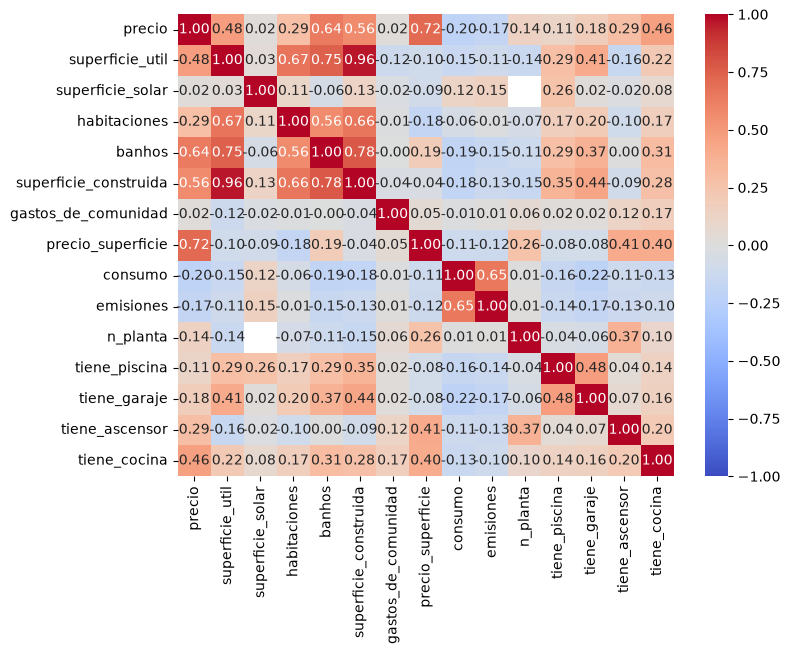

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_reducido.assign(gastos_de_comunidad=df_reducido['gastos_de_comunidad']!='0',tiene_cocina=~df_reducido['cocina_equipada'].isna()).corr(numeric_only=True,method='pearson'),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0
)
plt.show()

In [82]:
df_reducido['ascensor'].unique()

<StringArray>
[                             nan,                           'True',
                  'Lift elevator',                              '3',
                   '2 ascensores',                              '2',
              '2 ud. Por rellano',                 'Dos ascensores',
                     'En proceso',                              '5',
                   ' montacargas',                  'Y montacargas',
                'Tiene ascensor.',                          'False',
                              '4',                             'No',
 'Lo empiezan a instalar en 2026',                  '+ montacargas',
                   '+montacargas',             '2 recine cambiados',
  'Ascensor si pero este piso no']
Length: 21, dtype: str

In [29]:
x:pd.DataFrame=df_reducido[['superficie_construida','habitaciones','banhos','n_planta','consumo','emisiones','tiene_piscina','tiene_garaje','tiene_ascensor','conservacion','localidad_sin_numero','cp']].assign(tiene_cocina=~df_reducido['cocina_equipada'].isna()).dropna(subset=['superficie_construida'])
y:pd.Series=df_reducido.loc[x.index]['precio']

In [30]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.15,random_state=42)
xtrain:pd.DataFrame=cast(pd.DataFrame,xtrain)
xtest:pd.DataFrame=cast(pd.DataFrame,xtest)
ytrain:pd.Series=cast(pd.Series,ytrain)
ytest:pd.Series=cast(pd.Series,ytest)
xtrain.isna().sum()

superficie_construida       0
habitaciones              348
banhos                    349
n_planta                 2426
consumo                  8629
emisiones                8629
tiene_piscina             422
tiene_garaje              939
tiene_ascensor           1212
conservacion             3772
localidad_sin_numero        0
cp                       5755
tiene_cocina                0
dtype: int64

In [31]:
xtrain

,superficie_construida,habitaciones,banhos,n_planta,consumo,emisiones,tiene_piscina,tiene_garaje,tiene_ascensor,conservacion,localidad_sin_numero,cp,tiene_cocina
9850,94.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0,1.0,NaN,latina_aluche,28047,False
5132,84.0,3.0,2.0,1.0,NaN,NaN,1.0,1.0,1.0,A estrenar,apeadero_de_guadarrama,NaN,False
1063,161.0,4.0,1.0,0.0,NaN,NaN,0.0,0.0,0.0,A reformar,centro_casco_historico,28801,False
11342,58.0,2.0,1.0,5.0,NaN,NaN,0.0,0.0,1.0,NaN,numancia,NaN,False
7372,89.0,3.0,2.0,1.0,291.0,51.0,0.0,0.0,1.0,NaN,ciudad_lineal_pueblo_nuevo,28017,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14644,61.0,1.0,1.0,2.0,NaN,NaN,0.0,1.0,1.0,NaN,valdeacederas,NaN,True
7110,34.0,1.0,1.0,3.0,NaN,NaN,0.0,0.0,NaN,NaN,chamberi_arapiles,28015,True
7320,59.0,3.0,1.0,4.0,NaN,NaN,0.0,0.0,1.0,NaN,ciudad_lineal_pueblo_nuevo,NaN,False
1143,223.0,6.0,4.0,0.0,187.0,48.0,NaN,1.0,0.0,En buen estado,colmenar_de_oreja_centro_urbano,NaN,True


In [32]:
encoder:TargetEncoder=TargetEncoder(target_type='continuous')
encoder.set_output(transform='pandas')

scaler:StandardScaler=StandardScaler()
scaler.set_output(transform='pandas')

imputer:KNNImputer=KNNImputer()
imputer.set_output(transform='pandas')
columnas_a_encodear=['conservacion','localidad_sin_numero','cp']
train_encoded:pd.DataFrame=cast(pd.DataFrame,encoder.fit_transform(xtrain[columnas_a_encodear],ytrain))
xtrain=xtrain.assign(
    conservacion=train_encoded['conservacion'],
    localidad_sin_numero=train_encoded['localidad_sin_numero'],
    cp=train_encoded['cp'],
    # gastos_de_comunidad=train_encoded['gastos_de_comunidad'],
)
test_encoded:pd.DataFrame=cast(pd.DataFrame,encoder.transform(xtest[columnas_a_encodear]))
xtest=xtest.assign(
    conservacion=test_encoded['conservacion'],
    localidad_sin_numero=test_encoded['localidad_sin_numero'],
    cp=test_encoded['cp'],
    # gastos_de_comunidad=test_encoded['gastos_de_comunidad'],
)

xtrain_scaled:pd.DataFrame=cast(pd.DataFrame,scaler.fit_transform(xtrain))
xtest_scaled:pd.DataFrame=cast(pd.DataFrame,scaler.transform(xtest))
xtrain_scaled=cast(pd.DataFrame,imputer.fit_transform(xtrain_scaled))
xtest_scaled=cast(pd.DataFrame,imputer.transform(xtest_scaled))
xtrain=pd.DataFrame(
    scaler.inverse_transform(xtrain_scaled),
    index=xtrain_scaled.index,
    columns=xtrain_scaled.columns
)
xtest=pd.DataFrame(
    scaler.inverse_transform(xtest_scaled),
    index=xtest_scaled.index,
    columns=xtest_scaled.columns
)

In [33]:
model:LinearRegression=LinearRegression()
model.fit(xtrain,ytrain)
yhat:pd.Series=pd.Series(model.predict(xtest),name=ytest.name,index=ytest.index)
print(f"MAE: {mean_absolute_error(ytest, yhat)}")
print(f"MSE: {mean_squared_error(ytest, yhat)}")
print(f"RMSE: {root_mean_squared_error(ytest, yhat)}")
print(f"R2: {r2_score(ytest, yhat)}")

MAE: 156484.94283119956
MSE: 52001925240.38272
RMSE: 228039.30634954738
R2: 0.7528578696672593


In [11]:
ytest

6653      484000.0
8137      114335.0
6724     2050000.0
7741     1800000.0
15247     237000.0
           ...    
10128     250000.0
8719     2359000.0
7860      180000.0
13111     135000.0
10926     254000.0
Name: precio, Length: 1976, dtype: float64

In [12]:
yhat

6653     6.672225e+05
8137     2.672350e+05
6724     1.943180e+06
7741     1.168115e+06
15247    7.188672e+04
             ...     
10128    1.928394e+05
8719     1.506671e+06
7860     2.866035e+04
13111    1.313458e+05
10926    2.009908e+05
Name: precio, Length: 1976, dtype: float64

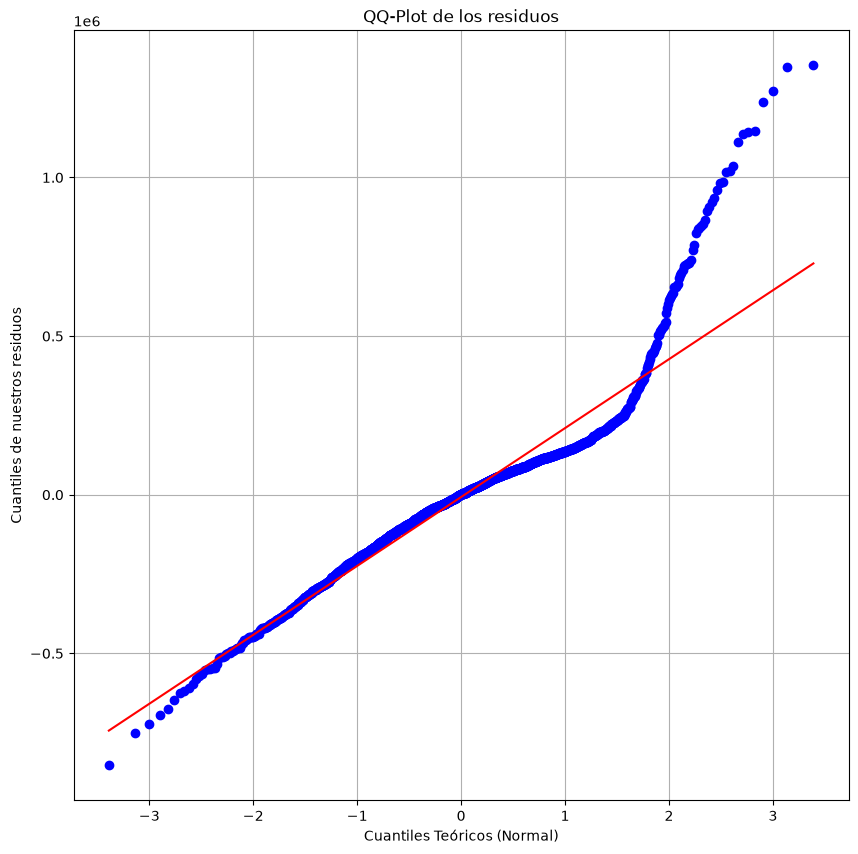

In [13]:
residuals=ytest-yhat
plt.figure(figsize=(10,10))
stats.probplot(residuals,dist='norm',plot=plt)
plt.title('QQ-Plot de los residuos')
plt.xlabel('Cuantiles Teóricos (Normal)')
plt.ylabel('Cuantiles de nuestros residuos')
plt.grid(True)
plt.show()

In [14]:
residuals.sort_values()

3792    -8.534255e+05
2996    -7.517725e+05
9388    -7.221829e+05
812     -6.938914e+05
1731    -6.765163e+05
             ...     
12804    1.146896e+06
12643    1.238475e+06
8783     1.271909e+06
381      1.348038e+06
13977    1.352914e+06
Name: precio, Length: 1976, dtype: float64